## Library

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statistics as st
import numpy as np
import copy 

from sklearn.compose import ColumnTransformer as ct
from sklearn.model_selection import train_test_split as tts, cross_val_score as cvs, GridSearchCV as gscv, RandomizedSearchCV as rscv
from sklearn.preprocessing import StandardScaler as ss, LabelEncoder as le, OneHotEncoder as ohe
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error as mae, mean_squared_error as mse, root_mean_squared_error as rmse, confusion_matrix as cm, accuracy_score as AS
from sklearn.tree import DecisionTreeClassifier as dtc
from sklearn.ensemble import RandomForestClassifier as rfc, GradientBoostingClassifier as gbc, AdaBoostClassifier

from xgboost import XGBClassifier as xgbc

import keras
from keras.layers import Dense, Input
from keras.models import Sequential

from scikeras.wrappers import KerasClassifier as kc

import random
import matplotlib.image as mpimg

from skimage import exposure
from skimage.util import random_noise
from skimage import transform
from cv2 import resize



## 1. Basics

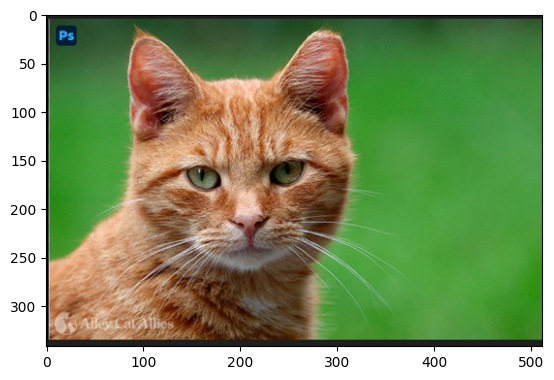

In [2]:
# image
img = mpimg.imread(r"D:\COURSE\DATA SCIENCE FULL COURSE BY UDEMY\cat_512x342.png")
plt.imshow(img)

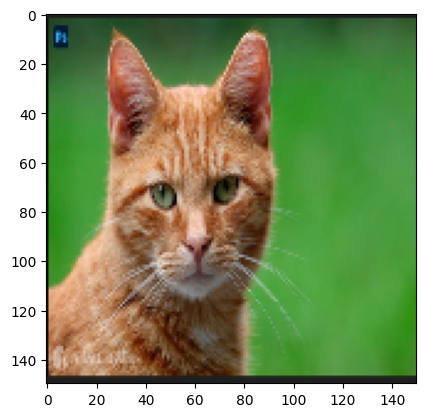

In [3]:
# Rescale Image
rescale_img = resize(img, (150, 150))
plt.imshow(rescale_img)

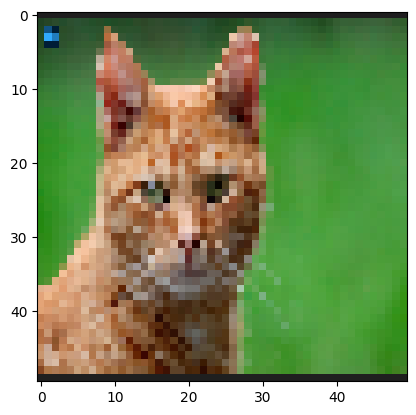

In [4]:
# 50*50 Pixel
img_50 = resize(img, (50, 50))
plt.imshow(img_50)

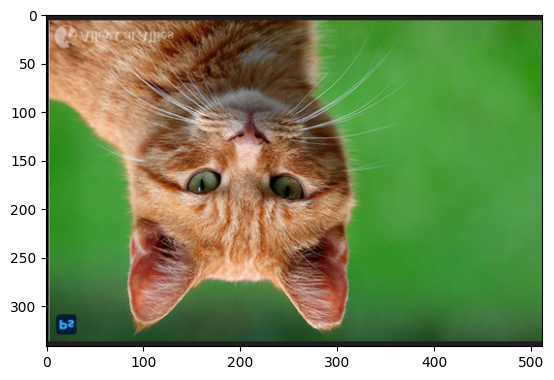

In [5]:
# Flipping

# Horizontal
horizontal_flip = np.fliplr(img)
plt.imshow(horizontal_flip)

# Vertical
vertical_flip = np.flipud(img)
plt.imshow(vertical_flip)


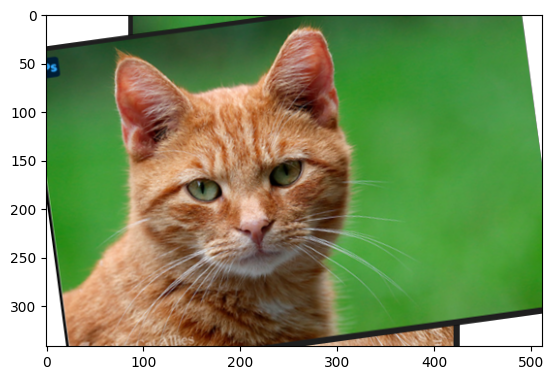

In [6]:
# Rotation
rotate_img = transform.rotate(img, angle=90)
plt.imshow(rotate_img)

# Rotation Random
rotate_img_random = transform.rotate(img, random.uniform(-40, 40))
plt.imshow(rotate_img_random)

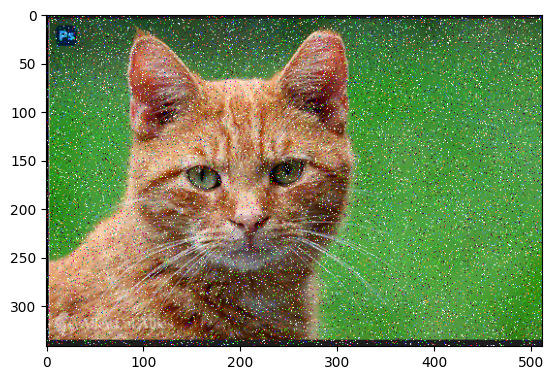

In [7]:
# Random Noise
noise_img = random_noise(img, mode='s&p', clip=True)
plt.imshow(noise_img)

## 2. Practical

In [2]:
# Library
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from sklearn.model_selection import cross_val_score as cvs, train_test_split as tts, GridSearchCV as gscv

from skimage import transform
from skimage import exposure
from skimage.util import random_noise
from cv2 import resize


from scikeras.wrappers import KerasClassifier as kc
from keras.models import Sequential
from keras.layers import Dense, Input

import tensorflow as tf
from tensorflow import keras
from keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Dense, Input, Dropout, Flatten

from keras.layers import Conv2D, MaxPooling2D
from keras import backend as K

In [3]:
num_classes = 10
batch_size = 64
epochs = 24

img_rows, img_cols = 28, 28  # Input Image Dimension

In [4]:
# Load Dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# X Shape
x_train.shape, x_test.shape

((60000, 28, 28), (10000, 28, 28))

In [5]:
# Y Shape
y_train.shape, y_test.shape

((60000,), (10000,))

In [6]:
x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1)
x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)
input_shape = (img_rows, img_cols, 1)

# Same
# x_train = x_train.reshape(x_train.shape[0], x_train.shape[1], x_train.shape[2], 1)
# x_test = x_test.reshape(x_test.shape[0], x_test.shape[1], x_test.shape[2], 1)
# input_shape = (img_rows, img_cols, 1)

print(x_train.shape)
print(x_test.shape)
input_shape

(60000, 28, 28, 1)
(10000, 28, 28, 1)


(28, 28, 1)

In [7]:
# Type Convert and Feture Scaling The Testing and Training 
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

# Feature Scaling
x_train /= 255.
x_test /= 255.

# Same
# x_train = x_train/255  # 255 Total Pixels
# x_test = x_test/255    # 0 is Black and 255 is White
print(y_train[0:3])

[9 0 0]


In [8]:
# Convert Class Vector to Binary Class Metrices. (Feature Encoding like One-Hot-Encoding)
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)
print(y_train[0:2])

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


#### CNN Code

In [9]:
# Define Model
model = Sequential()

# Create CNN TO Classify Image
model.add(Input(shape=input_shape))

model.add(
    Conv2D(
        filters=32, kernel_size=(3,3), activation='relu' 
    ))

model.add(
    MaxPooling2D(pool_size=(2, 2))
)

model.add(
    Conv2D(
        filters=32, kernel_size=(3,3), activation='relu')
    )

model.add(MaxPooling2D(
    pool_size=(2, 2)
))

model.add(Flatten())

model.add(Dense(
    units=128, activation='relu', bias_initializer='zeros', kernel_initializer='he_uniform'
))

model.add(Dense(
    units=64, kernel_initializer='he_uniform', activation='relu', bias_initializer='zeros'
))

# model.add(Dropout(0.5))

model.add(Dense(
    num_classes, activation='softmax'
))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train The Model with Training and Test Data after Each Cycle(epochs) through traiing Data
# Return history of loss and Accuracy for each epoch

hist = model.fit(x_train, y_train,
                 batch_size=batch_size,
                 epochs=epochs,
                 verbose=1,
                 validation_data=(x_test, y_test))

Epoch 1/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.8096 - loss: 0.5208 - val_accuracy: 0.8563 - val_loss: 0.3996
Epoch 2/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8763 - loss: 0.3405 - val_accuracy: 0.8650 - val_loss: 0.3683
Epoch 3/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.8932 - loss: 0.2913 - val_accuracy: 0.8824 - val_loss: 0.3152
Epoch 4/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.9041 - loss: 0.2608 - val_accuracy: 0.8946 - val_loss: 0.2830
Epoch 5/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.9122 - loss: 0.2364 - val_accuracy: 0.8975 - val_loss: 0.2807
Epoch 6/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.9182 - loss: 0.2196 - val_accuracy: 0.9032 - val_loss: 0.2661
Epoch 7/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.9250 - loss: 0.2019 - val_accuracy: 0.9078 - val_loss: 0.2550
Epoch 8/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.9308 - loss: 0.1834 - 

Test Loss     :  0.4248998463153839
Test Accuracy :  0.9046000242233276


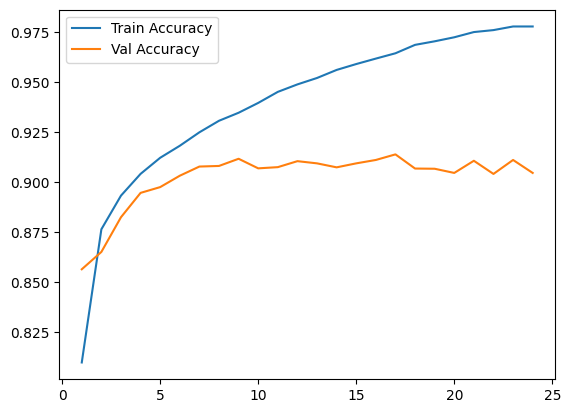

In [11]:
# Evaluate The Model on Test Data to get score on real data 
score = model.evaluate(x_test, y_test, verbose=0)
print('Test Loss     : ', score[0])
print('Test Accuracy : ', score[1])

# Plot Data of Relationship of Training and Validating Score
epoch_list= list(range(1, len(hist.history['accuracy']) +1 ))
plt.plot(epoch_list, hist.history['accuracy'], label='Train Accuracy')
plt.plot(epoch_list, hist.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.show()

In [12]:
history_data = pd.DataFrame(hist.history)
history_data

,accuracy,loss,val_accuracy,val_loss
0,0.809583,0.520809,0.8563,0.399594
1,0.876350,0.340539,0.8650,0.368324
2,0.893217,0.291289,0.8824,0.315167
3,0.904133,0.260824,0.8946,0.282981
4,0.912200,0.236388,0.8975,0.280736
5,0.918217,0.219555,0.9032,0.266088
6,0.924967,0.201894,0.9078,0.254999
7,0.930750,0.183379,0.9081,0.258870
8,0.934767,0.173088,0.9117,0.248891
9,0.939700,0.160627,0.9069,0.267006


Best epoch: 17


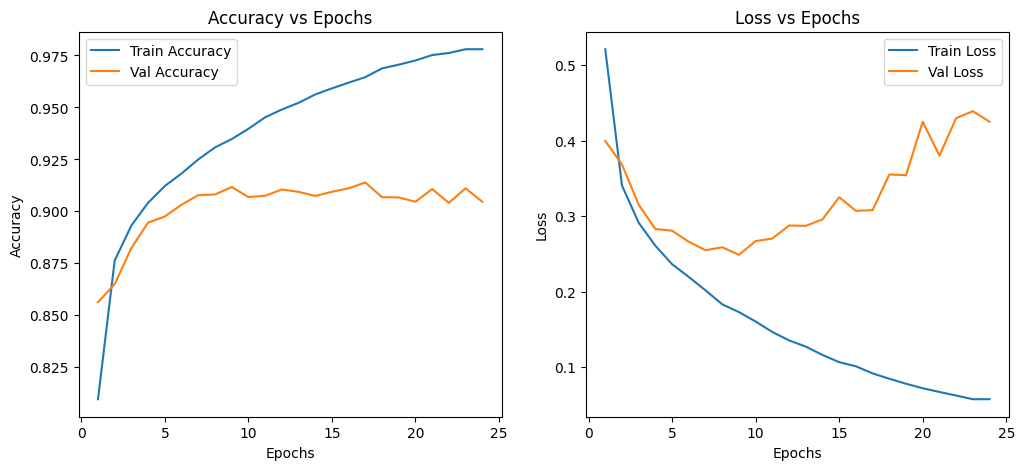

In [13]:
# Best Epoch
best_epoch = np.argmax(hist.history['val_accuracy'])
print("Best epoch:", best_epoch+1)

epoch_list = range(1, len(hist.history['accuracy']) + 1)

plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(epoch_list, hist.history['accuracy'], label='Train Accuracy')
plt.plot(epoch_list, hist.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(epoch_list, hist.history['loss'], label='Train Loss')
plt.plot(epoch_list, hist.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()

plt.show()

In [14]:
# Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 800)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         102,528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 363,008 (1.38 MB)

 Trainable params: 121,002 (472.66 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 242,006 (945.34 KB)